# Binary sentiment classification (positive/negative)

In [1]:
import warnings
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np

import re
import nltk
nltk.download('all')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
lemm = WordNetLemmatizer()

warnings.filterwarnings("ignore")

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_

# Loading the Dataset

In [2]:
data = pd.read_csv("Clothing-Review.csv")
data.head(7)

data = data[data['Class Name'].isnull() == False]

# Performing Exploratory Data Analysis

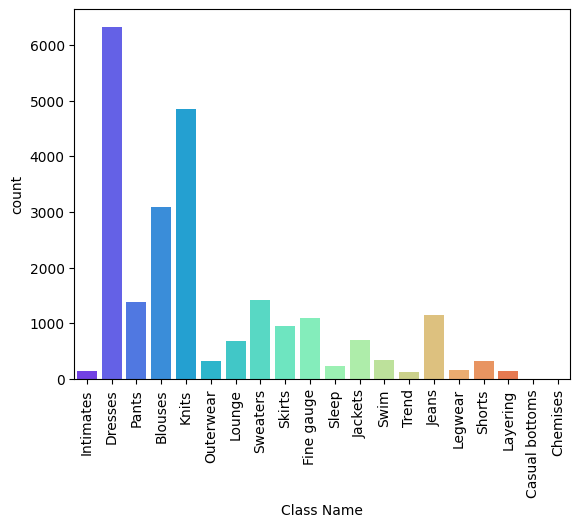

In [3]:
sns.countplot(data=data, x='Class Name', palette='rainbow')
plt.xticks(rotation=90)
plt.show()

# Count Plot of Rating and Recommendation Distribution

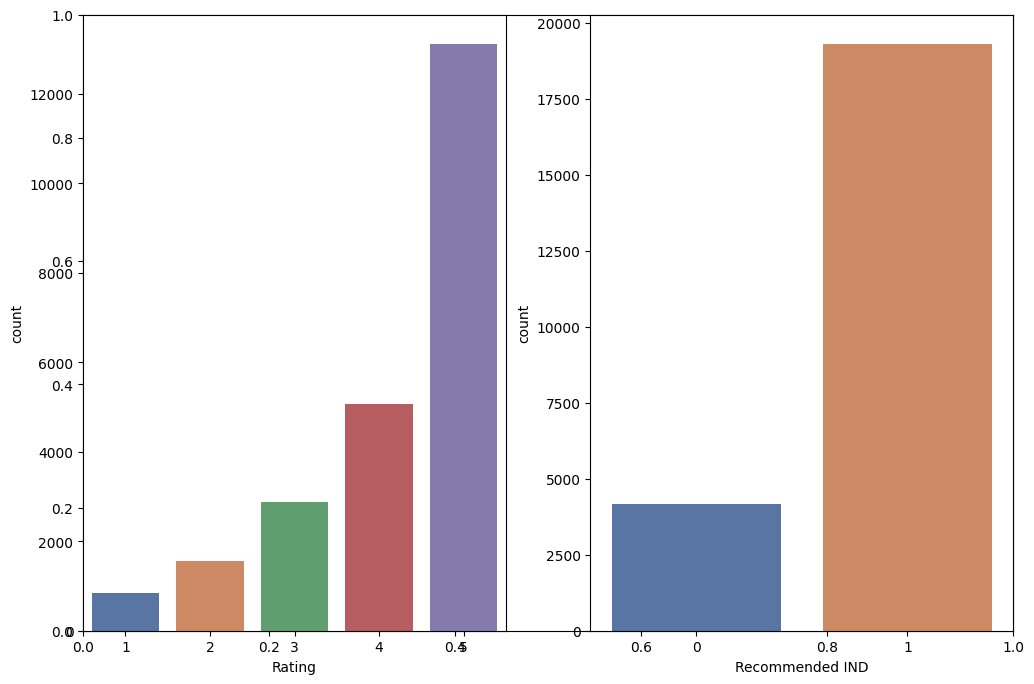

In [4]:
plt.subplots(figsize=(12, 8))
plt.subplot(1, 2, 1)
sns.countplot(data=data, x='Rating',palette="deep")

plt.subplot(1, 2, 2)
sns.countplot(data=data, x="Recommended IND", palette="deep")
plt.show()

# Histogram of Age Distribution

In [5]:
import plotly.io as pio
pio.renderers.default = "browser"

fig = px.histogram(
    data, marginal='box',
    x="Age", title="Age Group",
    color="Recommended IND",
    nbins=65-18,
    color_discrete_sequence=['green', 'red']
)
fig.update_layout(bargap=0.2)
fig.show()


Green bars represent recommended individuals; 
Red bars represent non-recommended individual

In [6]:
# Interpretation of Age Distribution Plot
fig = px.histogram(data,
                   x="Age",
                   marginal='box',
                   title="Age Group",
                   color="Rating",
                   nbins=65-18,
                   color_discrete_sequence
                   =['black', 'green', 'blue', 'red', 'yellow'])
fig.update_layout(bargap=0.2)

# Prepare the Data to build Model

In [7]:
'''Since the dataset is NLP-based, text columns are used as features and the Rating column is used for sentiment analysis. 
To handle class imbalance, ratings above 3 are converted to 1 (positive) and ratings below 3 are converted to 0 (negative).'''

def filter_score(rating):
    return int(rating > 3)

features = ['Class Name', 'Title', 'Review Text']

X = data[features]
y = data['Rating']
y = y.apply(filter_score)

# Text Preprocessing

In [9]:
def toLower(data):
    if isinstance(data, float):
        return '<UNK>'
    else:
        return data.lower()

stop_words = stopwords.words("english")

def remove_stopwords(text):
    no_stop = []
    for word in text.split(' '):
        if word not in stop_words:
            no_stop.append(word)
    return " ".join(no_stop)

def remove_punctuation_func(text):
    return re.sub(r'[^a-zA-Z0-9]', ' ', text)

X['Title'] = X['Title'].apply(toLower)
X['Review Text'] = X['Review Text'].apply(toLower)

X['Title'] = X['Title'].apply(remove_stopwords)
X['Review Text'] = X['Review Text'].apply(remove_stopwords)

X['Title'] = X['Title'].apply(lambda x: lemm.lemmatize(x))
X['Review Text'] = X['Review Text'].apply(lambda x: lemm.lemmatize(x))

X['Title'] = X['Title'].apply(remove_punctuation_func)
X['Review Text'] = X['Review Text'].apply(remove_punctuation_func)

X['Text'] = list(X['Title']+X['Review Text']+X['Class Name'])


X_train, X_test, y_train, y_test = train_test_split(
    X['Text'], y, test_size=0.25, random_state=42)

# Tokenization

In [10]:
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Padding the Text Data

In [11]:
train_seq = tokenizer.texts_to_sequences(X_train)
test_seq = tokenizer.texts_to_sequences(X_test)

train_pad = pad_sequences(train_seq,
                          maxlen=40,
                          truncating="post",
                          padding="post")
test_pad = pad_sequences(test_seq,
                         maxlen=40,
                         truncating="post",
                         padding="post")

# Building a Recurrent Neural Network (RNN) in TensorFlow

In [12]:
from tensorflow import keras

model = keras.models.Sequential()
model.add(keras.layers.Embedding(input_dim=10000, output_dim=128, input_length=40))
model.add(keras.layers.SimpleRNN(64, return_sequences=True))
model.add(keras.layers.SimpleRNN(64))
model.add(keras.layers.Dense(128, activation="relu"))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(1, activation="sigmoid"))

model.build(input_shape=(None, 40))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 40, 128)             │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ (None, 40, 64)              │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,309,057 (4.99 MB)

 Trainable params: 1,309,057 (4.99 MB)

 Non-trainable params: 0 (0.00 B)

# Training the Model

In [13]:
model.compile(loss="binary_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])
              

history = model.fit(train_pad,
                    y_train,
                    epochs=5)

Epoch 1/5
551/551 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.7941 - loss: 0.4697
Epoch 2/5
551/551 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.8404 - loss: 0.3937
Epoch 3/5
551/551 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.8795 - loss: 0.3081
Epoch 4/5
551/551 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.8942 - loss: 0.2872
Epoch 5/5
551/551 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.8396 - loss: 0.4045
